## Step 1: Import Required Libraries

In this step, we import all necessary libraries required for preprocessing the DeepFashion2 dataset for **Task 2: Detection and Segmentation**.

These libraries will help with:

- File system operations (`os`)
- JSON annotation parsing (`json`)
- Progress tracking (`tqdm`)
- Numerical operations (`numpy`)
- Image handling (`PIL`)
- PyTorch dataset utilities (`torch`, `Dataset`, `DataLoader`)
- Mask generation from polygons (`opencv`)

These tools will allow us to read annotation files, extract bounding boxes and segmentation polygons, and prepare the dataset for models such as **YOLO, Mask R-CNN, and U-Net**.

In [1]:
import os
import json
import random
from tqdm import tqdm
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import cv2

## Step 2: Define Dataset Paths

In this step, we define the directory paths for the **pruned DeepFashion2 dataset** stored on Kaggle.

The dataset is already organized into three splits:

- **Train**: used for model training
- **Validation**: used for model tuning and evaluation during training
- **Test**: used later for inference

Each split contains:
- an **images** folder containing `.jpg` files
- an **annos** folder containing corresponding `.json` annotation files

These paths will be used to load images and their annotations while constructing the detection and segmentation dataset.

In [2]:
BASE_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"

# Train paths
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train", "train", "images")
TRAIN_ANNO_DIR = os.path.join(BASE_PATH, "train", "train", "annos")

# Validation paths
VAL_IMG_DIR = os.path.join(BASE_PATH, "validation", "validation", "images")
VAL_ANNO_DIR = os.path.join(BASE_PATH, "validation", "validation", "annos")

# Test path (no annotations)
TEST_IMG_DIR = os.path.join(BASE_PATH, "test", "test", "images")

print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Train annos:", len(os.listdir(TRAIN_ANNO_DIR)))

print("Val images:", len(os.listdir(VAL_IMG_DIR)))
print("Val annos:", len(os.listdir(VAL_ANNO_DIR)))

print("Test images:", len(os.listdir(TEST_IMG_DIR)))

Train images: 144174
Train annos: 144174
Val images: 23741
Val annos: 23741
Test images: 62629


## Step 3: Define Category Mapping (Top-5 Classes)

During dataset pruning, only the **five most frequent clothing categories** were retained.

Original category IDs retained: `[1, 8, 7, 2, 9]`

These correspond to:
- 1 → Short sleeve top
- 8 → Trousers
- 7 → Shorts
- 2 → Long sleeve top
- 9 → Skirt

**Label Convention (important):**
- `0` is reserved for **background** (all pixels not covered by any clothing polygon)
- Foreground classes are mapped to indices **1–5**

This follows the standard segmentation convention required for Mask R-CNN and U-Net,
and matches the `label_map.json` file that will be saved for submission.

Original ID → New Class Index:
- 1 → 1 (short sleeve top)
- 8 → 2 (trousers)
- 7 → 3 (shorts)
- 2 → 4 (long sleeve top)
- 9 → 5 (skirt)

In [3]:
# Top 5 category IDs (ordered by frequency from prune_dataset step)
TOP5 = [1, 8, 7, 2, 9]

# Map original DeepFashion2 category IDs → class indices 1-5
# Index 0 is reserved for BACKGROUND (standard segmentation convention)
category_map = {cid: idx + 1 for idx, cid in enumerate(TOP5)}

NUM_CLASSES = 5  # number of foreground classes (not counting background)

CLASS_NAMES = [
    "__background__",   # 0
    "short sleeve top", # 1
    "trousers",         # 2
    "shorts",           # 3
    "long sleeve top",  # 4
    "skirt"             # 5
]

print("Category mapping (Original DeepFashion ID → New class index):")
for cid, idx in category_map.items():
    print(f"  Original ID {cid:2d} → Class {idx} ({CLASS_NAMES[idx]})")

print("\nNote: Class 0 = background (implicit, not annotated)")

Category mapping (Original DeepFashion ID → New class index):
  Original ID  1 → Class 1 (short sleeve top)
  Original ID  8 → Class 2 (trousers)
  Original ID  7 → Class 3 (shorts)
  Original ID  2 → Class 4 (long sleeve top)
  Original ID  9 → Class 5 (skirt)

Note: Class 0 = background (implicit, not annotated)


## Step 3b: Save `label_map.json`

As required for submission, we save a `label_map.json` file with the exact format specified.
This documents the foreground class name → label index mapping used throughout the project.
Background (index 0) is implicit and not listed.

In [4]:
# Save label_map.json in the exact required format
label_map = {
    "short sleeve top": 1,
    "trousers": 2,
    "shorts": 3,
    "long sleeve top": 4,
    "skirt": 5
}
# Note: background = 0 (implicit, all pixels not covered by any clothing polygon)

with open("label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("label_map.json saved.")
print(json.dumps(label_map, indent=4))
print("\n(Background = 0, implicit)")

label_map.json saved.
{
    "short sleeve top": 1,
    "trousers": 2,
    "shorts": 3,
    "long sleeve top": 4,
    "skirt": 5
}

(Background = 0, implicit)


## Step 4: Parse JSON Annotations for Detection and Segmentation

For Task 2, each image may contain **multiple clothing items**, so we must extract **instance-level information** from the annotation files.

From each JSON annotation, we extract:

- **Bounding boxes** → used for object detection
- **Category labels** → mapped class indices (1–5, with 0 reserved for background)
- **Segmentation polygons** → used to generate segmentation masks

Each valid item must belong to the selected **top-5 clothing categories**.

For every image, we store:

- `img_path` → path to the image
- `boxes` → list of bounding boxes `[x1, y1, x2, y2]`
- `labels` → mapped class indices (1–5)
- `polygons` → segmentation polygons

Images that **do not contain any of the selected categories** are skipped.

In [5]:
def create_detection_samples(img_dir, anno_dir):

    samples = []

    for anno_file in tqdm(os.listdir(anno_dir)):

        if not anno_file.endswith(".json"):
            continue

        img_id = anno_file.replace(".json", "")
        img_path = os.path.join(img_dir, img_id + ".jpg")
        anno_path = os.path.join(anno_dir, anno_file)

        if not os.path.exists(img_path):
            continue

        with open(anno_path, "r") as f:
            data = json.load(f)

        boxes = []
        labels = []
        polygons = []

        for item in data["items"]:

            if "category_id" not in item:
                continue

            cid = item["category_id"]

            if cid not in category_map:
                continue

            if "bbox" not in item:
                continue

            if "segmentation" not in item:
                continue

            if len(item["segmentation"]) == 0:
                continue

            # Labels are 1-5 (0 = background, reserved)
            label = category_map[cid]

            box = item["bbox"]
            seg = item["segmentation"]

            boxes.append(box)
            labels.append(label)
            polygons.append(seg)

        if len(boxes) == 0:
            continue

        samples.append({
            "img_path": img_path,
            "boxes": boxes,
            "labels": labels,
            "polygons": polygons
        })

    return samples

## Step 5: Create Detection Samples

Using the annotation parsing function defined earlier, we now generate the **detection dataset samples** for the training and validation splits.

Each sample will contain:

- `img_path` → path to the image
- `boxes` → list of bounding boxes for clothing items
- `labels` → mapped class labels (1–5) for each item
- `polygons` → segmentation polygons for each item

The resulting lists `train_det_samples` and `val_det_samples` will be used to build dataset loaders for **YOLO, Mask R-CNN, and U-Net**.

In [6]:
print("Creating training detection samples...")
train_det_samples = create_detection_samples(TRAIN_IMG_DIR, TRAIN_ANNO_DIR)

print("Creating validation detection samples...")
val_det_samples = create_detection_samples(VAL_IMG_DIR, VAL_ANNO_DIR)

print("Total training samples:", len(train_det_samples))
print("Total validation samples:", len(val_det_samples))

Creating training detection samples...


100%|██████████| 144174/144174 [18:26<00:00, 130.29it/s]


Creating validation detection samples...


100%|██████████| 23741/23741 [03:00<00:00, 131.74it/s]

Total training samples: 144174
Total validation samples: 23741


## Step 6: Inspect a Sample from the Detection Dataset

Before using the dataset for training detection and segmentation models, it is important to verify that the preprocessing step produced the correct structure.

We inspect one sample from the training dataset to confirm:

- The **image path** is correct.
- The **bounding boxes** are extracted properly.
- The **labels** are in range 1–5 (not 0–4).
- The **segmentation polygons** exist for each clothing item.

In [7]:
# Inspect one sample
sample = train_det_samples[0]

print("Image Path:")
print(sample["img_path"])

print("\nBounding Boxes:")
print(sample["boxes"][:3])

print("\nLabels (should be in range 1-5):")
print(sample["labels"][:3])
print("Label names:", [CLASS_NAMES[l] for l in sample["labels"][:3]])

print("\nPolygons (first object):")
print(sample["polygons"][0][:10])

Image Path:
/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/train/images/039350.jpg

Bounding Boxes:
[[209, 263, 387, 539]]

Labels (should be in range 1-5):
[2]
Label names: ['trousers']

Polygons (first object):
[[381, 306, 334, 289, 297, 266, 261, 350, 225, 451, 216, 482, 268, 501, 273, 465, 312, 368, 279, 465, 263, 513, 315, 534, 332, 482, 362, 389, 381, 306], [334, 289, 297, 266, 261, 350, 225, 451, 216, 482, 268, 501, 273, 465, 312, 368, 334, 289], [381, 306, 334, 289, 312, 368, 279, 465, 263, 513, 315, 534, 332, 482, 362, 389, 381, 306]]


## Step 7: Save Preprocessed Detection Samples

Parsing the DeepFashion2 annotations requires scanning **hundreds of thousands of JSON files**, which can take significant time.
To avoid repeating this step every time the notebook runs, we save the processed detection samples.

The following objects are saved:

- `train_detection_samples.pt` → training detection samples (labels 1–5)
- `val_detection_samples.pt` → validation detection samples (labels 1–5)
- `category_map.pt` → mapping from original category IDs to class indices 1–5
- `label_map.json` → human-readable label mapping for submission

In [8]:
SAVE_DIR = "/kaggle/working/preprocessed"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(train_det_samples, os.path.join(SAVE_DIR, "train_detection_samples.pt"))
torch.save(val_det_samples, os.path.join(SAVE_DIR, "val_detection_samples.pt"))
torch.save(category_map, os.path.join(SAVE_DIR, "category_map.pt"))

# Also copy label_map.json to SAVE_DIR
import shutil
shutil.copy("label_map.json", os.path.join(SAVE_DIR, "label_map.json"))

print("Detection preprocessing files saved successfully.")
print("Saved to:", SAVE_DIR)
print("Files:", os.listdir(SAVE_DIR))

Detection preprocessing files saved successfully.
Saved to: /kaggle/working/preprocessed
Files: ['val_detection_samples.pt', 'train_detection_samples.pt', 'category_map.pt', 'label_map.json']


## Step 8: Verify Saved Preprocessed Files

After saving the preprocessed detection samples, it is good practice to verify that the files were written correctly and can be loaded without errors.

In this step we:

- Load the saved files from `/kaggle/working/preprocessed`
- Check the number of samples
- Inspect the structure of one sample
- Confirm labels are in range 1–5

In [9]:
# Load saved files
train_loaded = torch.load(os.path.join(SAVE_DIR, "train_detection_samples.pt"))
val_loaded = torch.load(os.path.join(SAVE_DIR, "val_detection_samples.pt"))
cat_map_loaded = torch.load(os.path.join(SAVE_DIR, "category_map.pt"))

print("Loaded train samples:", len(train_loaded))
print("Loaded val samples:", len(val_loaded))
print("Loaded category map:", cat_map_loaded)

# Confirm all labels are in range 1-5 (not 0-4)
all_labels = [l for s in train_loaded for l in s["labels"]]
print("\nLabel range in train_loaded:")
print("  Min label:", min(all_labels), "(should be >= 1)")
print("  Max label:", max(all_labels), "(should be <= 5)")
print("  Unique labels:", sorted(set(all_labels)))

# Inspect one loaded sample
print("\nExample loaded sample:")
print("  img_path:", train_loaded[0]["img_path"])
print("  boxes:", train_loaded[0]["boxes"][:2])
print("  labels:", train_loaded[0]["labels"][:5])

Loaded train samples: 144174
Loaded val samples: 23741
Loaded category map: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}

Label range in train_loaded:
  Min label: 1 (should be >= 1)
  Max label: 5 (should be <= 5)
  Unique labels: [1, 2, 3, 4, 5]

Example loaded sample:
  img_path: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/train/images/039350.jpg
  boxes: [[209, 263, 387, 539]]
  labels: [2]


## Step 8B: Compute Class Weights for Weighted CE Loss

To handle **pixel-level class imbalance**, we compute per-class instance counts across all training samples.
Instance count is used as a proxy for pixel area (fast, no need to rasterize masks).

Class weights are computed using **inverse frequency weighting** so that minority classes
(e.g. skirt, shorts) receive higher weight during loss computation.

In [10]:
# =========================================================
# STEP 8B: COMPUTE CLASS WEIGHTS FOR WEIGHTED CE LOSS
# Fix for pixel-level class imbalance
# =========================================================

# Count how many annotation instances exist per class across all train samples.
# Labels are 1-5; background (0) is handled separately below.

label_counter = Counter()

for sample in train_det_samples:
    for label in sample["labels"]:
        label_counter[label] += 1

print("Instance count per class:")
total_instances = sum(label_counter.values())

for idx in range(1, NUM_CLASSES + 1):   # 1-5
    count = label_counter.get(idx, 0)
    print(f"  Class {idx} ({CLASS_NAMES[idx]:<20}): {count:>7}  ({100*count/total_instances:.1f}%)")

Instance count per class:
  Class 1 (short sleeve top    ):   71645  (31.1%)
  Class 2 (trousers            ):   55387  (24.0%)
  Class 3 (shorts              ):   36616  (15.9%)
  Class 4 (long sleeve top     ):   36064  (15.6%)
  Class 5 (skirt               ):   30835  (13.4%)


## Step 8C: Compute and Save Class Weights

Using the instance counts computed above, we build a weight tensor of length `NUM_CLASSES + 1` (background + 5 foreground classes).

- Index 0 → background weight (kept low since background dominates pixel area)
- Indices 1–5 → foreground class weights (inverse frequency weighted)

This tensor is passed as `weight=class_weights` to `nn.CrossEntropyLoss` during segmentation training.

In [11]:
# =========================================================
# STEP 8C: COMPUTE + SAVE CLASS WEIGHTS
# =========================================================

# Inverse frequency weighting — minority classes get higher weight
# Labels 1-5 correspond to CLASS_NAMES[1..5]
# Label 0 = background

fg_counts = np.array([label_counter.get(i, 1) for i in range(1, NUM_CLASSES + 1)])  # classes 1-5

# Background gets a low weight since it dominates mask area
bg_count = fg_counts.sum() * 10  # approximate: background pixels ~ 10x all fg instances

all_counts = np.array([bg_count] + list(fg_counts))   # index 0=bg, 1-5=fg
weights = 1.0 / (all_counts + 1)                      # inverse frequency
weights = weights / weights.sum() * len(weights)      # normalize: mean weight = 1.0

class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights (index 0 = background, 1-5 = clothing classes):")
print(f"  Index 0 (background)    : {class_weights[0]:.4f}")
for idx in range(1, NUM_CLASSES + 1):
    print(f"  Index {idx} ({CLASS_NAMES[idx]:<20}): {class_weights[idx]:.4f}")

# Save alongside other preprocessed files
torch.save(class_weights, os.path.join(SAVE_DIR, "class_weights.pt"))
print("\nclass_weights.pt saved to:", SAVE_DIR)

Class weights (index 0 = background, 1-5 = clothing classes):
  Index 0 (background)    : 0.0217
  Index 1 (short sleeve top    ): 0.6984
  Index 2 (trousers            ): 0.9034
  Index 3 (shorts              ): 1.3665
  Index 4 (long sleeve top     ): 1.3874
  Index 5 (skirt               ): 1.6227

class_weights.pt saved to: /kaggle/working/preprocessed


## Step 8D: Create Balanced Subset (Instance-Level)

Even after computing class weights, the raw dataset is heavily imbalanced.
To help models see all 5 classes equally during training, we build a **balanced subset** by:

1. Bucketing training samples by the class labels they contain
2. Sampling an equal number of images per class bucket

This results in a balanced training subset of 20,000 samples and a balanced validation subset of 5,000 samples.

In [12]:
# =========================================================
# STEP 8D: CREATE BALANCED SUBSET (instance-level)
# Ensures equal representation of all 5 classes
# =========================================================

def build_balanced_subset(data, target_size):
    """
    Bucket samples by their LABELS (already remapped 1-5).
    Samples equal number per class to produce a balanced subset.
    """
    class_buckets = defaultdict(list)

    for sample in data:
        for label in set(sample["labels"]):  # labels are 1-5
            class_buckets[int(label)].append(sample)

    classes = sorted(class_buckets.keys())
    per_class = target_size // len(classes)

    print(f"\nBuilding balanced subset: {per_class} samples per class")
    for c in classes:
        print(f"  Class {c} ({CLASS_NAMES[c]:<20}): {len(class_buckets[c])} available, "
              f"taking {min(per_class, len(class_buckets[c]))}")

    subset = []
    for c in classes:
        samples = class_buckets[c]
        random.shuffle(samples)
        subset.extend(samples[:per_class])

    random.shuffle(subset)
    return subset[:target_size]


TRAIN_TARGET = 20000
VAL_TARGET   = 5000

train_balanced = build_balanced_subset(train_det_samples, TRAIN_TARGET)
val_balanced   = build_balanced_subset(val_det_samples,   VAL_TARGET)

print(f"\nBalanced train size: {len(train_balanced)}")
print(f"Balanced val size:   {len(val_balanced)}")

# Verify class distribution in balanced subset
balanced_counter = Counter()
for sample in train_balanced:
    for label in sample["labels"]:
        balanced_counter[label] += 1

print("\nClass distribution in balanced train subset:")
for idx in range(1, NUM_CLASSES + 1):
    print(f"  Class {idx} ({CLASS_NAMES[idx]:<20}): {balanced_counter.get(idx, 0)}")


Building balanced subset: 4000 samples per class
  Class 1 (short sleeve top    ): 70586 available, taking 4000
  Class 2 (trousers            ): 54969 available, taking 4000
  Class 3 (shorts              ): 36332 available, taking 4000
  Class 4 (long sleeve top     ): 35751 available, taking 4000
  Class 5 (skirt               ): 30625 available, taking 4000

Building balanced subset: 1000 samples per class
  Class 1 (short sleeve top    ): 12371 available, taking 1000
  Class 2 (trousers            ): 9494 available, taking 1000
  Class 3 (shorts              ): 4133 available, taking 1000
  Class 4 (long sleeve top     ): 5916 available, taking 1000
  Class 5 (skirt               ): 6499 available, taking 1000

Balanced train size: 20000
Balanced val size:   5000

Class distribution in balanced train subset:
  Class 1 (short sleeve top    ): 9750
  Class 2 (trousers            ): 7256
  Class 3 (shorts              ): 5860
  Class 4 (long sleeve top     ): 6760
  Class 5 (skirt  

## Step 8E: Save Balanced Subsets

We save the balanced training and validation subsets alongside the full dataset.

Training notebooks for Mask R-CNN, YOLO, and U-Net should load these balanced files by default,
and fall back to the full dataset only if needed for evaluation.

- `train_detection_samples_balanced.pt` — 20,000 balanced training samples
- `val_detection_samples_balanced.pt` — 5,000 balanced validation samples

In [13]:
# =========================================================
# STEP 8E: SAVE BALANCED SUBSETS
# =========================================================

torch.save(train_balanced, os.path.join(SAVE_DIR, "train_detection_samples_balanced.pt"))
torch.save(val_balanced,   os.path.join(SAVE_DIR, "val_detection_samples_balanced.pt"))

print("Balanced samples saved:")
print(f"  train_detection_samples_balanced.pt  ({len(train_balanced)} samples)")
print(f"  val_detection_samples_balanced.pt    ({len(val_balanced)} samples)")
print("\nAll files in SAVE_DIR:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(" ", f)

Balanced samples saved:
  train_detection_samples_balanced.pt  (20000 samples)
  val_detection_samples_balanced.pt    (5000 samples)

All files in SAVE_DIR:
  category_map.pt
  class_weights.pt
  label_map.json
  train_detection_samples.pt
  train_detection_samples_balanced.pt
  val_detection_samples.pt
  val_detection_samples_balanced.pt


## Step 9: Visualize Bounding Boxes and Segmentation

To ensure that the preprocessing pipeline correctly extracted bounding boxes and segmentation polygons, we visualize a sample image from the training dataset.

This step overlays:
- **Bounding boxes** around clothing items
- **Segmentation polygons** representing precise clothing outlines
- **Class labels** (1–5) with their human-readable names

Visual inspection helps verify that:
- Bounding boxes align with clothing items
- Segmentation polygons correctly trace the item boundaries
- Labels are correct and in range 1–5

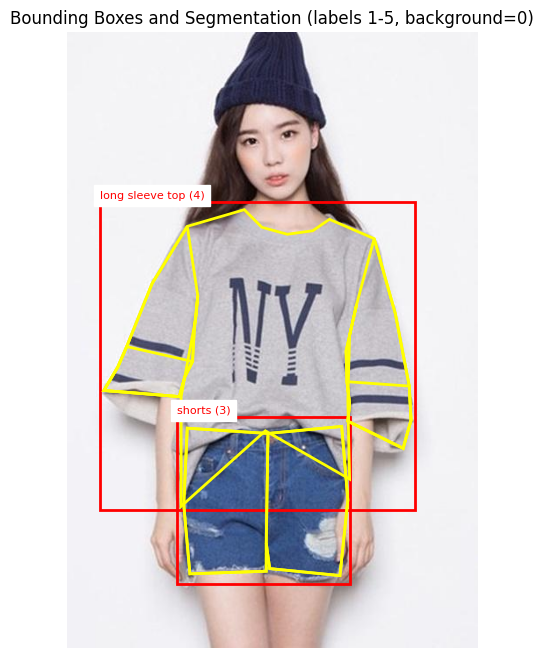

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Select a random sample
sample = random.choice(train_loaded)

img_path = sample["img_path"]
boxes    = sample["boxes"]
labels   = sample["labels"]
polygons = sample["polygons"]

# Load image
image = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(image)

# Draw bounding boxes with label names
for box, label in zip(boxes, labels):
    x1, y1, x2, y2 = box
    width  = x2 - x1
    height = y2 - y1

    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, f"{CLASS_NAMES[label]} ({label})",
            color='red', fontsize=8, backgroundcolor='white')

# Draw segmentation polygons
for poly_group in polygons:
    for poly in poly_group:
        pts = np.array(poly).reshape(-1, 2)
        polygon = patches.Polygon(
            pts, linewidth=2, edgecolor='yellow', fill=False
        )
        ax.add_patch(polygon)

plt.title("Bounding Boxes and Segmentation (labels 1-5, background=0)")
plt.axis("off")
plt.show()